In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'


from gsmo.hist_features_uni import extract_embeddings
from gsmo.utils import *
from gsmo import GSMO, GSMOConfig
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import random

seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")


CUDA is available. GPU: NVIDIA GeForce RTX 3090


In [2]:
import os
os.chdir('data/spatial-mux-seq/E13_20um')

In [3]:
rna = sc.read('scRNA.h5ad')
spatial_coords = rna.obs[['x', 'y']].copy()
spatial_coords = spatial_coords.values
rna_feat = preprocess(rna, modality='rna')

protein = sc.read('scProtein.h5ad')
protein_feat = preprocess(protein, modality='protein')

H3K27me3 = sc.read('H3K27me3_seurat_object.h5ad')
H3K27me3_feat = H3K27me3.obsm['X_lsi']

H3K4me3 = sc.read('H3K4me3_seurat_object.h5ad')
H3K4me3_feat = H3K4me3.obsm['X_lsi']


/home/user2/miniconda3/envs/testuni6/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


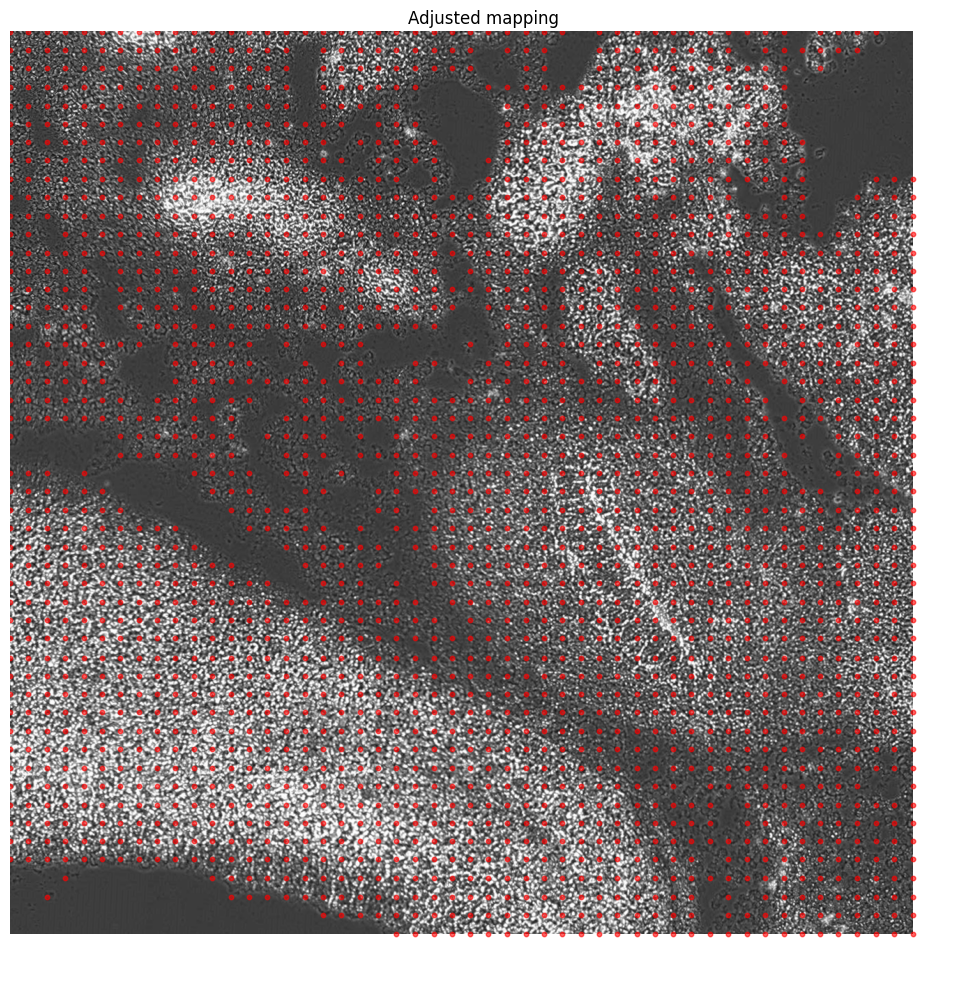

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

img = Image.open("tissue_lowres_image.png").convert("RGB")
img = img.transpose(Image.ROTATE_90)
img = img.transpose(Image.FLIP_TOP_BOTTOM)
img_np = np.array(img)

import pandas as pd


def extract_coords_from_index(index):
    coords = [i.split('x') for i in index]
    coords = np.array(coords, dtype=float)
    return coords

coords = np.array(spatial_coords)# extract_coords_from_index(rna.index)

def normalize_coords_adjustable(coords, image_shape, scale_factors=(1.0, 1.0), shift=(0, 0)):
    """
    coords: original coordinates [N, 2]
    image_shape: (H, W, C)
    scale_factors: (scale_x, scale_y)
    shift: (shift_x_pixels, shift_y_pixels)
    """
    x_min, y_min = coords.min(axis=0)
    x_max, y_max = coords.max(axis=0)
    coords_norm = (coords - [x_min, y_min]) / ([x_max - x_min, y_max - y_min])
    

    coords_norm[:, 0] = coords_norm[:, 0] * scale_factors[0] + (1 - scale_factors[0]) / 2
    coords_norm[:, 1] = coords_norm[:, 1] * scale_factors[1] + (1 - scale_factors[1]) / 2
    
    coords_img = coords_norm * [image_shape[1], image_shape[0]]
    coords_img[:, 0] += shift[0]
    coords_img[:, 1] += shift[1]
    
    return coords_img.astype(int)

coords_img_adj = normalize_coords_adjustable(
    coords,
    img_np.shape,
    scale_factors=(1.0, 1.0),  
    shift=(0, 0)
)

plt.figure(figsize=(10, 10))
plt.imshow(img_np)
plt.scatter(coords_img_adj[:, 0], coords_img_adj[:, 1], s=10, c='red', alpha=0.6)
plt.title("Adjusted mapping")
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:

from tqdm import tqdm
from gsmo.hist_features_uni import extract_embeddings, extract_patch, get_embeddings_uni2
def extract_patch_safe(img, center_x, center_y, patch_size):
    
    h, w, _ = img.shape
    patch = np.ones((patch_size, patch_size, 3), dtype=np.uint8) * 255  

    half = patch_size // 2
    start_x = center_x - half
    start_y = center_y - half
    end_x = center_x + half
    end_y = center_y + half

    img_x1 = max(start_x, 0)
    img_x2 = min(end_x, w)
    img_y1 = max(start_y, 0)
    img_y2 = min(end_y, h)

    patch_x1 = img_x1 - start_x
    patch_x2 = patch_x1 + (img_x2 - img_x1)
    patch_y1 = img_y1 - start_y
    patch_y2 = patch_y1 + (img_y2 - img_y1)

    patch[patch_y1:patch_y2, patch_x1:patch_x2] = img[img_y1:img_y2, img_x1:img_x2]
    return patch


def extract_embeddings_with_adjusted_coords(
    img,
    coords,
    scale_factors=(0.98, 0.91),
    shift=(0, -9),
    patch_size=42,
    device='cuda'
):
    if isinstance(img, Image.Image):
        img = np.array(img.convert("RGB"))

    image_shape = img.shape
    coords = coords
    coords_img = normalize_coords_adjustable(coords, image_shape, scale_factors, shift)

    embeddings = np.zeros((coords_img.shape[0], 1536), dtype=np.float32)

    for i, (x, y) in enumerate(tqdm(coords_img, desc="Extracting embeddings with adjusted coords")):
        patch = extract_patch_safe(img, x, y, patch_size)
        emb = get_embeddings_uni2(patch)
        embeddings[i] = emb

    return embeddings, coords_img


def extract_embeddings_batch_dualscale(
    img,
    coords_img,
    patch_sizes=(24, 32),
    batch_size=128,
    device='cuda'
):
    import torch
    from gsmo.hist_features_uni import model, transform

    if isinstance(img, Image.Image):
        img = np.array(img.convert("RGB"))

    model.eval()
    model.to(device)

    all_patches_small = []
    all_patches_large = []

    for (x, y) in coords_img:
        patch_small = extract_patch_safe(img, x, y, patch_sizes[0])
        patch_large = extract_patch_safe(img, x, y, patch_sizes[1])
        all_patches_small.append(patch_small)
        all_patches_large.append(patch_large)

    def patches_to_tensor(patch_list):
        return torch.stack([transform(Image.fromarray(p)) for p in patch_list])

    patch_tensors_small = patches_to_tensor(all_patches_small)
    patch_tensors_large = patches_to_tensor(all_patches_large)

    embeddings = []
    with torch.inference_mode():
        for i in tqdm(range(0, len(coords_img), batch_size), desc="Extracting dual-scale embeddings"):
            batch_s = patch_tensors_small[i:i+batch_size].to(device)
            batch_l = patch_tensors_large[i:i+batch_size].to(device)

            emb_s = model(batch_s).cpu().numpy()  # [B, 1536]
            emb_l = model(batch_l).cpu().numpy()
            emb = np.concatenate([emb_s, emb_l], axis=1)  # [B, 3072]
            embeddings.append(emb)

    return np.concatenate(embeddings, axis=0)


embeddings = extract_embeddings_batch_dualscale(
    img=img,
    coords_img=coords_img_adj,
    patch_sizes=(36, 72), # (42, 96),   
    batch_size=256,
    device='cuda'
)

print("embedding shape:", embeddings.shape)  # [N, 3072]

np.save("image_embeddings.npy", embeddings)


Extracting dual-scale embeddings: 100%|██████████| 9/9 [01:38<00:00, 10.90s/it]

embedding shape: (2224, 3072)


In [6]:
from sklearn.preprocessing import StandardScaler

coords = coords_img_adj

image_embeddings = np.load("image_embeddings.npy")  # [N, 1536]
assert image_embeddings.shape[0] == rna.shape[0]

print("Multimodal input ready!")


Multimodal input ready!


In [ ]:
features_dict = {
        'rna': rna_feat,        
        'protein': protein_feat,       
        'h3k27me3': H3K27me3_feat,  
        'h3k4me3': H3K4me3_feat,    
        'image': image_embeddings
    }

initial_weights = [1.0, 1.0, 1.0, 1.0, 1.0]  

cfg = GSMOConfig
cfg.max_hidden_layers=3

model = GSMO(features_dict, spatial_coords=spatial_coords, device=device, cfg=cfg,
            trainable_weights=True, initial_weights=initial_weights)

model.load_state_dict(torch.load("best_model_fig.pth"))

/home/user2/miniconda3/envs/testuni6/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


<All keys matched successfully>

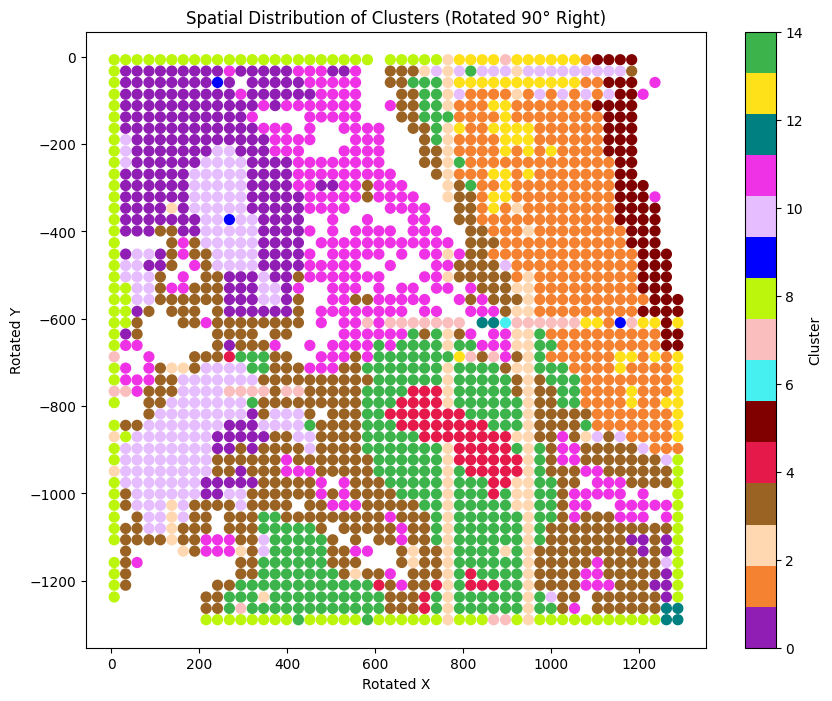

In [8]:
# visualization of cluster results

from matplotlib.colors import ListedColormap
plot_color = ['#911eb4','#f58231', '#ffd8b1', '#9a6324',  '#e6194b', '#800000', '#46f0f0', '#fabebe', 
              '#bcf60c', '#0000ff', '#e6beff', '#f032e6', '#008080', '#ffe119', '#3cb44b', '#aaffc3', '#808000', 
              '#000075', '#000000', '#808080', '#ffffff', '#fffac8', '#D1D1D1']  

rna = sc.read('scRNA.h5ad')


assert 'x' in rna.obs.columns and 'y' in rna.obs.columns, "The RNA data is missing spatial coordinates or has an incorrect format. Please check the data."


rna_locs = rna.obs[['x', 'y']].copy()


# rna_locs = rna.obsm['spatial'] 
assert rna_locs is not None and rna_locs.shape[1] == 2, "The RNA data is missing spatial coordinates or has an incorrect format. Please check the data."

clusters = model.cluster_kmeans(n_clusters=15)

rna_locs_df = pd.DataFrame(rna_locs, columns=['x', 'y'])  
rna_locs_df['cluster'] = clusters  

num_clusters = len(np.unique(clusters))

if num_clusters > len(plot_color):
    raise ValueError(f"Cluster number {num_clusters} exceeds the number of colors available in the custom palette {len(plot_color)}.")

cmap = ListedColormap(plot_color[:num_clusters])
rna_locs_df['x_rot'] = rna_locs_df['y']
rna_locs_df['y_rot'] = -rna_locs_df['x']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(rna_locs_df['x_rot'], rna_locs_df['y_rot'], c=rna_locs_df['cluster'], cmap=cmap, s=50)
plt.colorbar(scatter, label="Cluster")
plt.title("Spatial Distribution of Clusters (Rotated 90° Right)")
plt.xlabel('Rotated X')
plt.ylabel('Rotated Y')
plt.show()



/home/user2/miniconda3/envs/testuni6/lib/python3.10/site-packages/scanpy/tools/_utils.py:40: UserWarning: You’re trying to run this on 48440 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

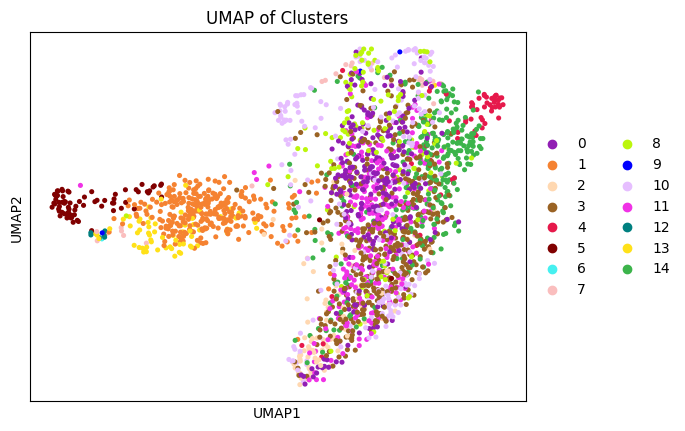

In [9]:
# UMAP

from matplotlib.colors import ListedColormap

rna = sc.read('scRNA.h5ad')

clusters = model.cluster_kmeans(n_clusters=15)

rna.obs['cluster'] = clusters.astype(str)  

if 'X_umap' not in rna.obsm:
    sc.pp.neighbors(rna)         
    sc.tl.umap(rna)              
num_clusters = len(np.unique(clusters))

if num_clusters > len(plot_color):
    raise ValueError(f"Cluster number {num_clusters} exceeds the number of colors available in the custom palette {len(plot_color)}.")

cmap = ListedColormap(plot_color[:num_clusters])

plt.figure(figsize=(8, 6))
sc.pl.umap(rna, color='cluster', palette=plot_color[:num_clusters], title='UMAP of Clusters', show=True)


In [10]:
# two unsupervised metrics

import skimage
from sklearn.metrics import pairwise_distances
import numpy as np
from tqdm import tqdm

def compute_jaccard_similarity(Z_m, Z_e, k=50):

    dist_m = pairwise_distances(Z_m)
    dist_e = pairwise_distances(Z_e)
    
    n = Z_m.shape[0]
    jaccard_scores = []

    for i in tqdm(range(n), desc="Calculating Jaccard similarities"):
        neighbors_m = set(np.argsort(dist_m[i])[1:k+1])  # exclude self
        neighbors_e = set(np.argsort(dist_e[i])[1:k+1])
        intersection = len(neighbors_m & neighbors_e)
        union = len(neighbors_m | neighbors_e)
        jaccard = intersection / union if union > 0 else 0.0
        jaccard_scores.append(jaccard)

    return np.array(jaccard_scores), np.mean(jaccard_scores)


import squidpy as sq


def compute_morans_I(labels, spatial_coords, label_name="cluster_label"):

    adata = sc.AnnData(X=np.zeros((len(labels), 1)))  # dummy
    adata.obs[label_name] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    sq.gr.spatial_autocorr(adata, mode="moran", genes=label_name, attr="obs")

    moran_result = adata.uns["moranI"].loc[label_name, "I"]
    return moran_result


# rna_features: shape (n, d1)
# fused_embeddings: shape (n, d2)
# cluster_labels: shape (n,)
# spatial_coords: shape (n, 2)
fused_embeddings = model.get_embeddings()


# 1. Jaccard
jaccard_all, jaccard_mean = compute_jaccard_similarity(rna_feat, fused_embeddings, k=50)
print(f"Mean Jaccard RNA Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(protein_feat, fused_embeddings, k=50)
print(f"Mean Jaccard protein Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(H3K27me3_feat, fused_embeddings, k=50)
print(f"Mean Jaccard H3K27me3 Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(H3K4me3_feat, fused_embeddings, k=50)
print(f"Mean Jaccard H3K4me3 Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(image_embeddings, fused_embeddings, k=50)
print(f"Mean Jaccard image Similarity: {jaccard_mean:.4f}")

cluster_labels = model.cluster_kmeans(n_clusters=15)
morans_I = compute_morans_I(cluster_labels, spatial_coords)
print(f"Moran's I score: {morans_I:.4f}")

/home/user2/miniconda3/envs/testuni6/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/user2/miniconda3/envs/testuni6/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
Calculating Jaccard similarities: 100%|██████████| 2224/2224 [00:00<00:00, 6580.86it/s]


Mean Jaccard RNA Similarity: 0.0160


Calculating Jaccard similarities: 100%|██████████| 2224/2224 [00:00<00:00, 6513.34it/s]


Mean Jaccard protein Similarity: 0.0570


Calculating Jaccard similarities: 100%|██████████| 2224/2224 [00:00<00:00, 6497.83it/s]


Mean Jaccard H3K27me3 Similarity: 0.0415


Calculating Jaccard similarities: 100%|██████████| 2224/2224 [00:00<00:00, 6537.38it/s]


Mean Jaccard H3K4me3 Similarity: 0.0376


Calculating Jaccard similarities: 100%|██████████| 2224/2224 [00:00<00:00, 6577.63it/s]


Mean Jaccard image Similarity: 0.1278
Moran's I score: 0.5248


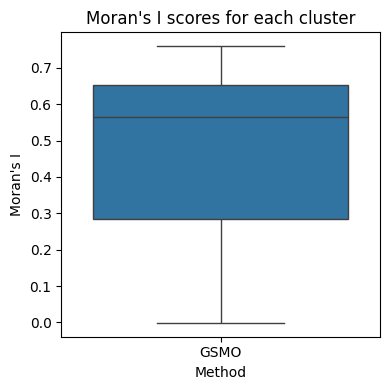

   cluster   moran_I method
0        0  0.686615   GSMO
1        1  0.756247   GSMO
2        2  0.252302   GSMO
3        3  0.563680   GSMO
4        4  0.648428   GSMO
5        5  0.759530   GSMO
6        6 -0.000600   GSMO
7        7  0.182898   GSMO
8        8  0.394848   GSMO
9        9 -0.001276   GSMO
10      10  0.596364   GSMO
11      11  0.657090   GSMO
12      12  0.387311   GSMO
13      13  0.316057   GSMO
14      14  0.621127   GSMO


In [11]:
# Moran's I box plot

import seaborn as sns

def compute_morans_I_per_method(labels, spatial_coords, method_name="MethodA"):
    
    adata = sc.AnnData(X=np.zeros((len(labels), 1)))
    adata.obs["cluster_label"] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    moran_scores = []
    unique_labels = np.unique(labels)

    for label in unique_labels:
        binary_vector = (labels == label).astype(int)
        adata.obs["tmp_binary"] = binary_vector

        sq.gr.spatial_autocorr(adata, mode="moran", genes="tmp_binary", attr="obs")
        I_score = adata.uns["moranI"].loc["tmp_binary", "I"]
        moran_scores.append({
            "cluster": str(label),
            "moran_I": I_score,
            "method": method_name
        })

    df_moran = pd.DataFrame(moran_scores)

    plt.figure(figsize=(4, 4))
    sns.boxplot(data=df_moran, x="method", y="moran_I")
    plt.title("Moran's I scores for each cluster")
    plt.ylabel("Moran's I")
    plt.xlabel("Method")
    plt.tight_layout()
    plt.show()

    return df_moran

morans_I_df = compute_morans_I_per_method(cluster_labels, spatial_coords, method_name="GSMO")
print(morans_I_df)


/home/user2/miniconda3/envs/testuni6/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


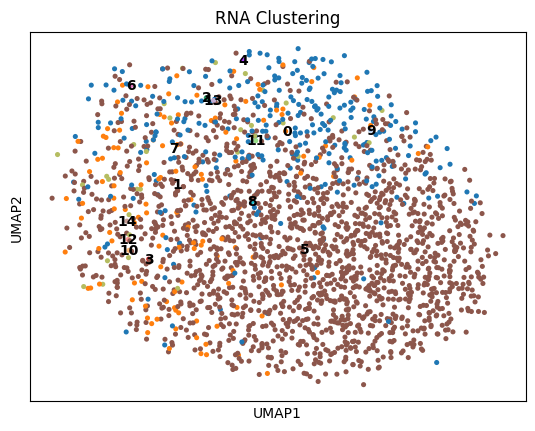

Figure saved to rna.png with dpi=600


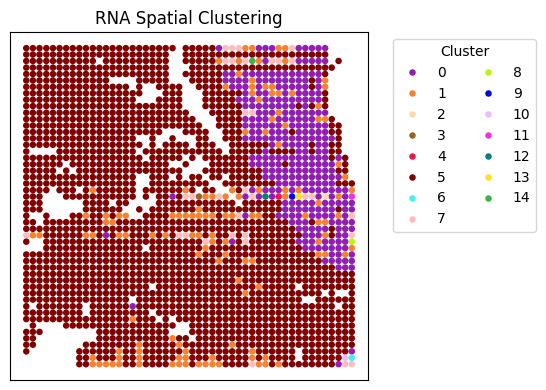

"run_clustering(H3K4me3, modality_name='H3K4me3', n_clusters=15)\nH3K4me3.obs['H3K4me3_cluster'] = H3K4me3.obs['H3K4me3_cluster'].astype(str)\nplot_spatial_clusters(H3K4me3, 'H3K4me3', cluster_key='H3K4me3_cluster', palette=custom_palette, save_path='h3k4me3.png')"

In [12]:
# single modality clustering results

import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.decomposition import PCA

rna = sc.read('scRNA.h5ad')
rna_feat = preprocess(rna, modality='rna')
protein = sc.read('scProtein.h5ad')
protein_feat = preprocess(protein, modality='protein')

H3K27me3 = sc.read('H3K27me3_seurat_object.h5ad')
H3K27me3_feat = H3K27me3.obsm['X_lsi']


H3K4me3 = sc.read('H3K4me3_seurat_object.h5ad')
H3K4me3_feat = H3K4me3.obsm['X_lsi']

def run_clustering(adata, modality_name, n_clusters=15):
    
    adata.obsm['feat'] = H3K4me3_feat
    X = adata.obsm['feat']
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(X)
    adata.obs[f'{modality_name}_cluster'] = kmeans.labels_.astype(str)

    sc.pp.neighbors(adata, use_rep='feat')
    sc.tl.umap(adata)
    
    sc.pl.umap(adata, color=f'{modality_name}_cluster', title=f'{modality_name} Clustering', legend_loc='on data')
import matplotlib.pyplot as plt
import seaborn as sns

def plot_spatial_clusters(adata, modality_name, cluster_key, title=None, point_size=22,palette=None, save_path=None, dpi=600):
    coords = spatial_coords
    cluster_labels = adata.obs[cluster_key]

    plt.figure(figsize=(5.6, 4))
    ax = sns.scatterplot(x=coords[:, 1], y=-coords[:, 0], hue=cluster_labels, hue_order=sorted(custom_palette.keys(), key=lambda x: int(x)), palette=palette, s=point_size, linewidth=0)
    #plt.gca().invert_yaxis()
    #plt.gca().invert_xaxis() 
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.title(title or f'{modality_name} Spatial Clustering')
    #plt.xlabel('X')
    #plt.ylabel('Y')
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to {save_path} with dpi={dpi}")
    plt.show()
plot_color = ['#911eb4','#f58231', '#ffd8b1', '#9a6324',  '#e6194b', '#800000', '#46f0f0', '#fabebe', 
              '#bcf60c', '#0000ff', '#e6beff', '#f032e6', '#008080', '#ffe119', '#3cb44b', '#aaffc3', '#808000', 
              '#000075', '#000000', '#808080', '#ffffff', '#fffac8', '#D1D1D1'] 
custom_palette = {str(i): plot_color[i] for i in range(15)}  
# 先聚类
run_clustering(rna, modality_name='RNA', n_clusters=15)
rna.obs['RNA_cluster'] = rna.obs['RNA_cluster'].astype(str)
plot_spatial_clusters(rna, 'RNA', cluster_key='RNA_cluster', palette=custom_palette, save_path='rna.png')

'''run_clustering(protein, modality_name='protein', n_clusters=15)
protein.obs['protein_cluster'] = protein.obs['protein_cluster'].astype(str)
plot_spatial_clusters(protein, 'protein', cluster_key='protein_cluster', palette=custom_palette, save_path='protein.png')'''

'''run_clustering(H3K27me3, modality_name='H3K27me3', n_clusters=15)
H3K27me3.obs['H3K27me3_cluster'] = H3K27me3.obs['H3K27me3_cluster'].astype(str)
plot_spatial_clusters(H3K27me3, 'H3K27me3', cluster_key='H3K27me3_cluster', palette=custom_palette, save_path='h3k27me3.png')'''

'''run_clustering(H3K4me3, modality_name='H3K4me3', n_clusters=15)
H3K4me3.obs['H3K4me3_cluster'] = H3K4me3.obs['H3K4me3_cluster'].astype(str)
plot_spatial_clusters(H3K4me3, 'H3K4me3', cluster_key='H3K4me3_cluster', palette=custom_palette, save_path='h3k4me3.png')'''

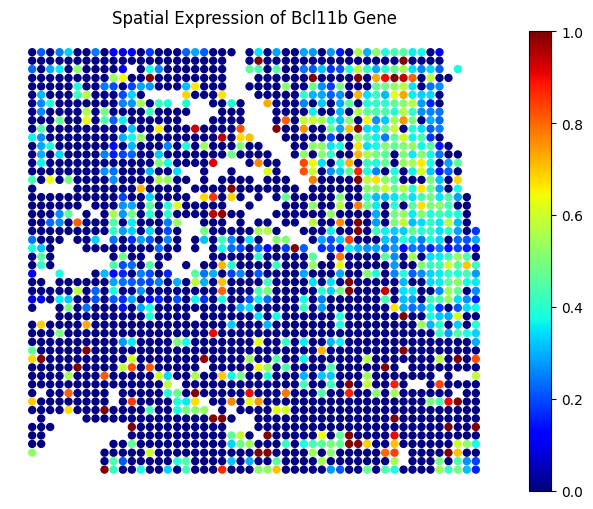

In [13]:
# heatmap of expressions of selected genes
# mainly focus on Col1a2、Elavl2、Hmga2、Sox2、Pax3、Bcl11b gene
 
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

rna = sc.read('scRNA.h5ad')
adata_p = rna
sc.pp.normalize_total(adata_p, target_sum=1e4) 
sc.pp.scale(adata_p, zero_center=True) 


if 'Bcl11b' not in adata_p.var_names:
    print("The Bcl11b gene is not in the dataset. Please confirm if the Bcl11b gene exists in the data.")
else:
    
    cux1_expression = adata_p[:, 'Bcl11b'].X.toarray().flatten() 

    cux1_expression_zscore = (cux1_expression - np.mean(cux1_expression)) / np.std(cux1_expression)
   
    scaled_cux1 = np.clip(cux1_expression_zscore, -1, 2) # 
    
    scaled_cux1 = np.interp(scaled_cux1, (scaled_cux1.min(), scaled_cux1.max()), (0, 1))
    
    x = spatial_coords[:, 1]
    y = -spatial_coords[:, 0]


    plt.figure(figsize=(6.4, 5.2))
    scatter = plt.scatter(x, y, c=scaled_cux1, cmap='jet', s=25, alpha=1.0)
    plt.colorbar(scatter)
    plt.title("Spatial Expression of Bcl11b Gene")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


/home/user2/miniconda3/envs/testuni6/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:235: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


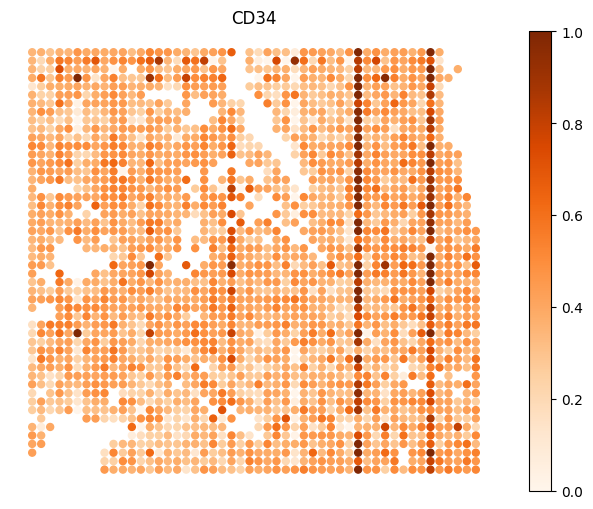

: 

In [ ]:
# heat map of expressions of selected proteins
# mainly focus on CD3、CD4、CD133、CD140a、B220、CD90.1、CD90.2、CD34 proteins

import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

protein = sc.read('scProtein.h5ad')
adata_p = protein
sc.pp.normalize_total(adata_p, target_sum=1e4) 
sc.pp.scale(adata_p, zero_center=True) 


if 'CD34' not in adata_p.var_names:
    print("The CD34 protein is not in the dataset. Please confirm if the CD34 protein exists in the data.")
else:
    cux1_expression = adata_p[:, 'CD34'].X.toarray().flatten() 

    cux1_expression_zscore = (cux1_expression - np.mean(cux1_expression)) / np.std(cux1_expression)
    # scaled_cux1 = cux1_expression_zscore
    scaled_cux1 = np.clip(cux1_expression_zscore, -1, 1.5) # 
    
    scaled_cux1 = np.interp(scaled_cux1, (scaled_cux1.min(), scaled_cux1.max()), (0, 1))
    x = spatial_coords[:, 1]
    y = -spatial_coords[:, 0]
    plt.figure(figsize=(6.4, 5.2))
    scatter = plt.scatter(x, y, c=scaled_cux1, cmap='Oranges', s=25, alpha=1.0)
    plt.colorbar(scatter)
    plt.title("CD34")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
